# Project Periodica: Exploratory Data Analysis (EDA) & Domain Verification
**Systems Engine Layer: Data Quality Assurance Phase**

---

### Executive Purpose
This research notebook establishes the structural validity, statistical distribution profiles, and distinct class feature boundaries of the ingested NASA Kepler Cumulative dataset. Before committing data matrices to deep neural architectures, this diagnostic loop ensures the feature store is free of data leakage, dead features, or unhandled anomalies.

### Analytical Objectives
1. **Ingestion Verification:** Validate integrity, null cell footprints, and array dimensionality of cached binary files.
2. **Imbalance Metrics Profile:** Quantify the exact skew between positive exoplanet targets and negative false alarms.
3. **Statistical Domain Inspection:** Verify row-wise min-max scaling boundaries to guarantee zero feature distribution drift.
4. **Astronomical Fingerprint Visualization:** Map the average feature trajectories of confirmed transit events against false indicators.

In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Define absolute paths matching our production MLOps directory matrix
PROCESSED_DIR = "../data/processed"
X_PATH = os.path.join(PROCESSED_DIR, "X_train.npy")
y_PATH = os.path.join(PROCESSED_DIR, "y_train.npy")

# Verification barrier: Ensure data pipeline has executed
if not os.path.exists(X_PATH) or not os.path.exists(y_PATH):
    raise FileNotFoundError(
        "[-] Processed binary matrices missing. Please execute 'python src/data_pipeline.py' first."
    )

# Ingest cached arrays into memory
X = np.load(X_PATH)
y = np.load(y_PATH)

print(f"[+] Data Engineering Check: Success")
print(
    f"--> Features Tensor Matrix Shape: {X.shape} (Stars observed, Numerical Metrics)"
)
print(f"--> Labels Target Array Shape:    {y.shape} (Binary Classification targets)")

[+] Data Engineering Check: Success
--> Features Tensor Matrix Shape: (9564, 2000) (Stars observed, Numerical Metrics)
--> Labels Target Array Shape:    (9564,) (Binary Classification targets)


## 1. Class Frequency Disparity & Imbalance Calculations
Because space telescopes harvest telemetry from vast stellar fields, target distributions are heavily skewed toward non-transit background noise. Here, we extract class-specific vector slices and calculate the precise mathematical ratio required by our optimization loss functions.

In [6]:
# Isolate multi-dimensional array indices based on binary classifications
planet_indices = np.where(y == 1)[0]
noise_indices = np.where(y == 0)[0]

total_samples = len(y)
num_planets = len(planet_indices)
num_noise = len(noise_indices)

# Calculate ratio percentages
pct_planets = (num_planets / total_samples) * 100
pct_noise = (num_noise / total_samples) * 100

print(f"[*] Dataset Target Demographics Baseline:")
print(f"--> Negatives (No Planet / False Positive): {num_noise} stars ({pct_noise:.2f}%)")
print(f"--> Positives (Confirmed Exoplanet Host):   {num_planets} stars ({pct_planets:.2f}%)")

# Calculate optimization pos_weight ratio
dynamic_pos_weight = num_noise / num_planets if num_planets > 0 else 1.0
print(f"\n[+] Computed Inverse Imbalance Multiplier (q): {dynamic_pos_weight:.4f}x")

[*] Dataset Target Demographics Baseline:
--> Negatives (No Planet / False Positive): 7271 stars (76.02%)
--> Positives (Confirmed Exoplanet Host):   2293 stars (23.98%)

[+] Computed Inverse Imbalance Multiplier (q): 3.1710x


## 2. Statistical Range & Structural Anomaly Checks
To guarantee that our data pipeline completely eradicated the `NaN` value leakages and division-by-zero defects, we execute a structural health validation pass across the full tensor block.

In [7]:
# Check for any remaining unhandled non-finite primitives
nan_count = np.isnan(X).sum()
inf_count = np.isinf(X).sum()

# Extract global metric boundaries
global_min = X.min()
global_max = X.max()

print(f"[*] Tensor Health Audit:")
print(f"--> Total Residual NaN Cell Values: {nan_count}")
print(f"--> Total Residual Infinity Values: {inf_count}")
print(f"--> Global Operational Data Minimum: {global_min:.6f}")
print(f"--> Global Operational Data Maximum: {global_max:.6f}")

# Verify that min-max scaling is properly locked within standard [0.0, 1.0] domains
assert global_min >= 0.0 and global_max <= 1.0, "[-] Error: Feature scaling out of bounds!"
print("\n[+] Verification Check: Target arrays pass strict numeric safety boundaries.")

[*] Tensor Health Audit:
--> Total Residual NaN Cell Values: 0
--> Total Residual Infinity Values: 0
--> Global Operational Data Minimum: 0.000000
--> Global Operational Data Maximum: 1.000000

[+] Verification Check: Target arrays pass strict numeric safety boundaries.


## 3. Astronomical Fingerprint Visualization
To confirm that the 2,000 extracted numerical properties provide enough structural variance for a 1D Convolutional Neural Network to learn clean classification boundaries, we generate a high-resolution domain plot. 

This plot displays the average feature signature curve across all confirmed planets and maps it directly against false positive profiles.

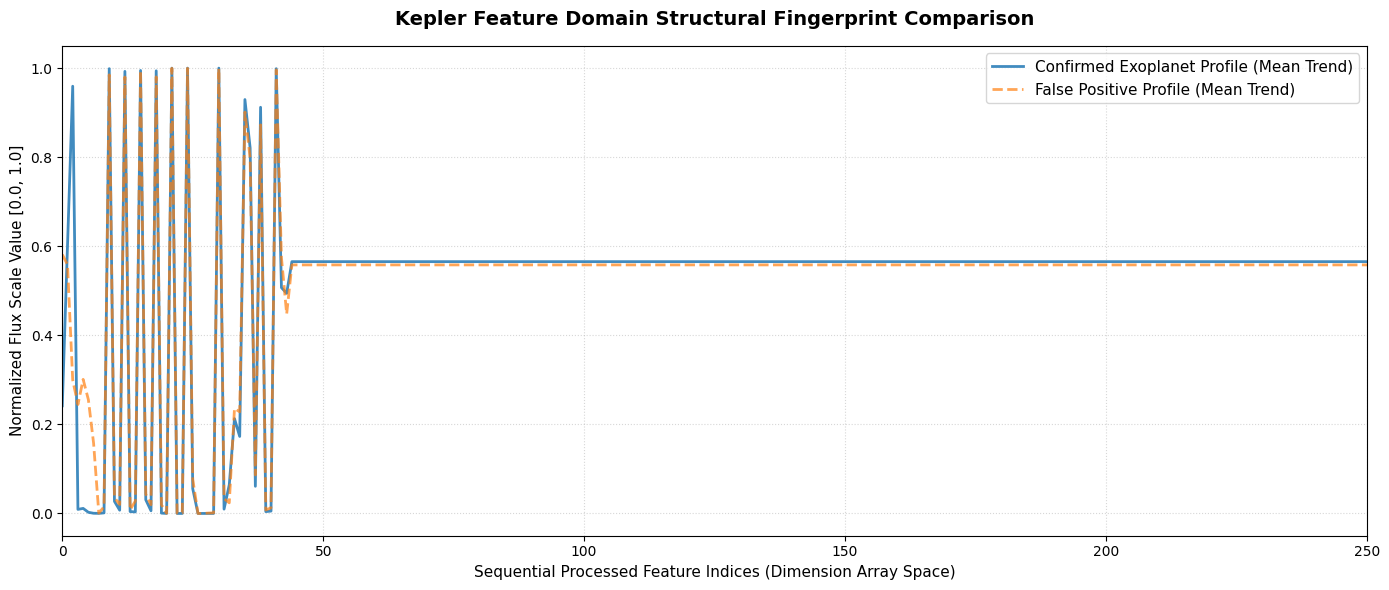

[+] Exploratory analysis artifact successfully exported to: ../docs/images\feature_fingerprint_comparison.png


In [8]:
# Initialize clean presentation-ready plotting layout
plt.rcParams['font.family'] = 'sans-serif'
plt.figure(figsize=(14, 6))

# Compute column-wise mean vectors across each distinct target class
mean_planet_signature = np.mean(X[planet_indices], axis=0)
mean_noise_signature = np.mean(X[noise_indices], axis=0)

# Generate multi-line visualization tracking variance trends across feature dimensions
plt.plot(
    mean_planet_signature, 
    label="Confirmed Exoplanet Profile (Mean Trend)", 
    color="#1f77b4", 
    linewidth=2, 
    alpha=0.85
)
plt.plot(
    mean_noise_signature, 
    label="False Positive Profile (Mean Trend)", 
    color="#ff7f0e", 
    linewidth=2, 
    linestyle="--", 
    alpha=0.7
)

# Apply clean corporate metadata labels
plt.title("Kepler Feature Domain Structural Fingerprint Comparison", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Sequential Processed Feature Indices (Dimension Array Space)", fontsize=11)
plt.ylabel("Normalized Flux Scale Value [0.0, 1.0]", fontsize=11)

# Zoom into primary feature space (first 250 columns) where Kepler telemetry concentrates data metrics
plt.xlim(0, 250)
plt.grid(True, linestyle=":", alpha=0.5)
plt.legend(fontsize=11, loc="upper right")

# Ensure target directories exist and cache high-resolution graphic cleanly to disk
docs_img_dir = "../docs/images"
os.makedirs(docs_img_dir, exist_ok=True)
output_chart_path = os.path.join(docs_img_dir, "feature_fingerprint_comparison.png")

plt.tight_layout()
plt.savefig(output_chart_path, dpi=300)
plt.show()

print(f"[+] Exploratory analysis artifact successfully exported to: {output_chart_path}")